# 3x5 Campaign Plot Analysis

This notebook reads the saved 3 manager x 5 worker campaign artifacts from the local `ResNet_trigger` node and makes cleaner analysis plots than the demo notebook.

It uses these files:
- `results.tsv`
- `artifacts/campaign_3x5_records.json`
- `artifacts/campaign_3x5_summary.json`
- `artifacts/campaign_3x5_auc.svg`
- `artifacts/run_archive/*.json`

If `matplotlib` is missing in your notebook kernel, install it in that environment first.

In [1]:
from pathlib import Path
import csv
import json
import math

import numpy as np
import matplotlib.pyplot as plt
from IPython.display import SVG, display

ROOT = Path('/Users/wongdowling/Documents/autoresearch_harness/nodes/ResNet_trigger')
ARTIFACT_DIR = ROOT / 'artifacts'
RESULTS_PATH = ROOT / 'results.tsv'
RECORDS_PATH = ARTIFACT_DIR / 'campaign_3x5_records.json'
SUMMARY_PATH = ARTIFACT_DIR / 'campaign_3x5_summary.json'
SVG_PATH = ARTIFACT_DIR / 'campaign_3x5_auc.svg'
RUN_ARCHIVE_DIR = ARTIFACT_DIR / 'run_archive'

for path in [RESULTS_PATH, RECORDS_PATH, SUMMARY_PATH, SVG_PATH, RUN_ARCHIVE_DIR]:
    if not path.exists():
        raise FileNotFoundError(path)

print('root:', ROOT)
print('results:', RESULTS_PATH)
print('records:', RECORDS_PATH)
print('summary:', SUMMARY_PATH)
print('run_archive_count:', len(list(RUN_ARCHIVE_DIR.glob('*.json'))))

root: /Users/wongdowling/Documents/autoresearch_harness/nodes/ResNet_trigger
results: /Users/wongdowling/Documents/autoresearch_harness/nodes/ResNet_trigger/results.tsv
records: /Users/wongdowling/Documents/autoresearch_harness/nodes/ResNet_trigger/artifacts/campaign_3x5_records.json
summary: /Users/wongdowling/Documents/autoresearch_harness/nodes/ResNet_trigger/artifacts/campaign_3x5_summary.json
run_archive_count: 16


In [2]:
rows = list(csv.DictReader(RESULTS_PATH.open(), delimiter='\t'))
records = json.loads(RECORDS_PATH.read_text())
summary = json.loads(SUMMARY_PATH.read_text())

for index, row in enumerate(rows, start=0):
    row['run_index'] = index
    row['val_bpb'] = float(row['val_bpb'])
    row['val_auc'] = 1.0 - row['val_bpb']

running_best = []
best_so_far = None
for row in rows:
    best_so_far = row['val_auc'] if best_so_far is None else max(best_so_far, row['val_auc'])
    running_best.append(best_so_far)

manager_round_labels = ['baseline'] + [record['manager_round'] for record in records]
worker_labels = [row['description'] for row in rows]

keep_rows = [row for row in rows if row['status'] == 'keep']
best_row = max(rows, key=lambda row: row['val_auc'])

print('baseline_val_auc:', rows[0]['val_auc'])
print('best_val_auc:', best_row['val_auc'])
print('improvement_over_baseline:', best_row['val_auc'] - rows[0]['val_auc'])
print('keep_count:', len(keep_rows))

baseline_val_auc: 0.779911
best_val_auc: 0.787556
improvement_over_baseline: 0.007645000000000013
keep_count: 5


In [3]:
print('Campaign summary from saved JSON:')
print(json.dumps(summary, indent=2))

print('\nKeep runs:')
for row in keep_rows:
    print(f"{row['run_index']:>2}  {row['description']:<45}  status={row['status']:<7}  val_auc={row['val_auc']:.6f}")

Campaign summary from saved JSON:
{
  "best_val_auc": 0.787556,
  "baseline_val_auc": 0.779911,
  "improvement_over_baseline": 0.007645,
  "plot_path": "/var/folders/mf/cqjfz_8x7tgbhvl955fzybtr0000gn/T/resnet-trigger-3x5-rgwe7mpl/ResNet_trigger/artifacts/campaign_3x5_auc.svg"
}

Keep runs:
 0  baseline                                       status=keep     val_auc=0.779911
 1  R1W1: Set LEARNING_RATE = 0.0005               status=keep     val_auc=0.782756
10  R2W5: Set STAGE_LAYERS = [1, 1, 2]             status=keep     val_auc=0.786756
13  R3W3: Set WEIGHT_DECAY = 0.00003               status=keep     val_auc=0.787111
14  R3W4: Set DROPOUT = 0.02                       status=keep     val_auc=0.787556


## Saved SVG Plot

This is the lightweight SVG plot exported during the automated run.

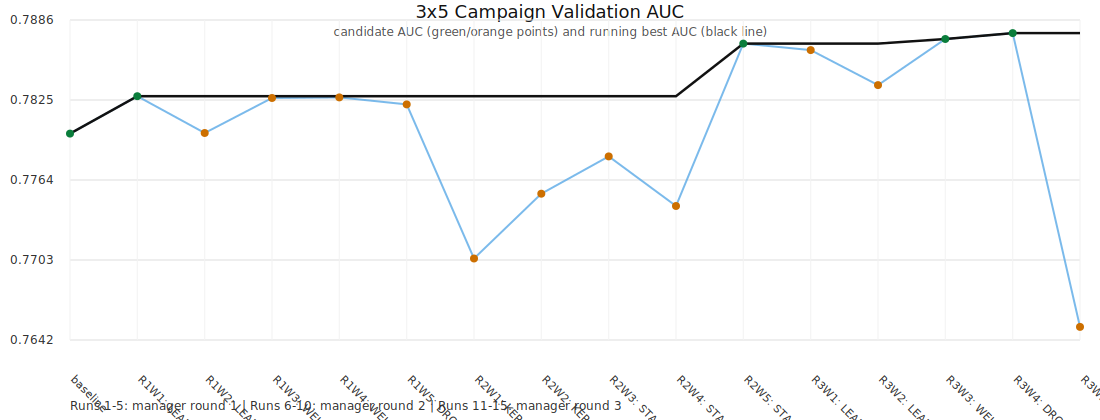

In [4]:
display(SVG(filename=str(SVG_PATH)))

## Better Matplotlib Plots

These plots show:
- candidate AUC by run
- running best AUC
- grouped performance by manager round
- a 3x5 heatmap for the worker slots

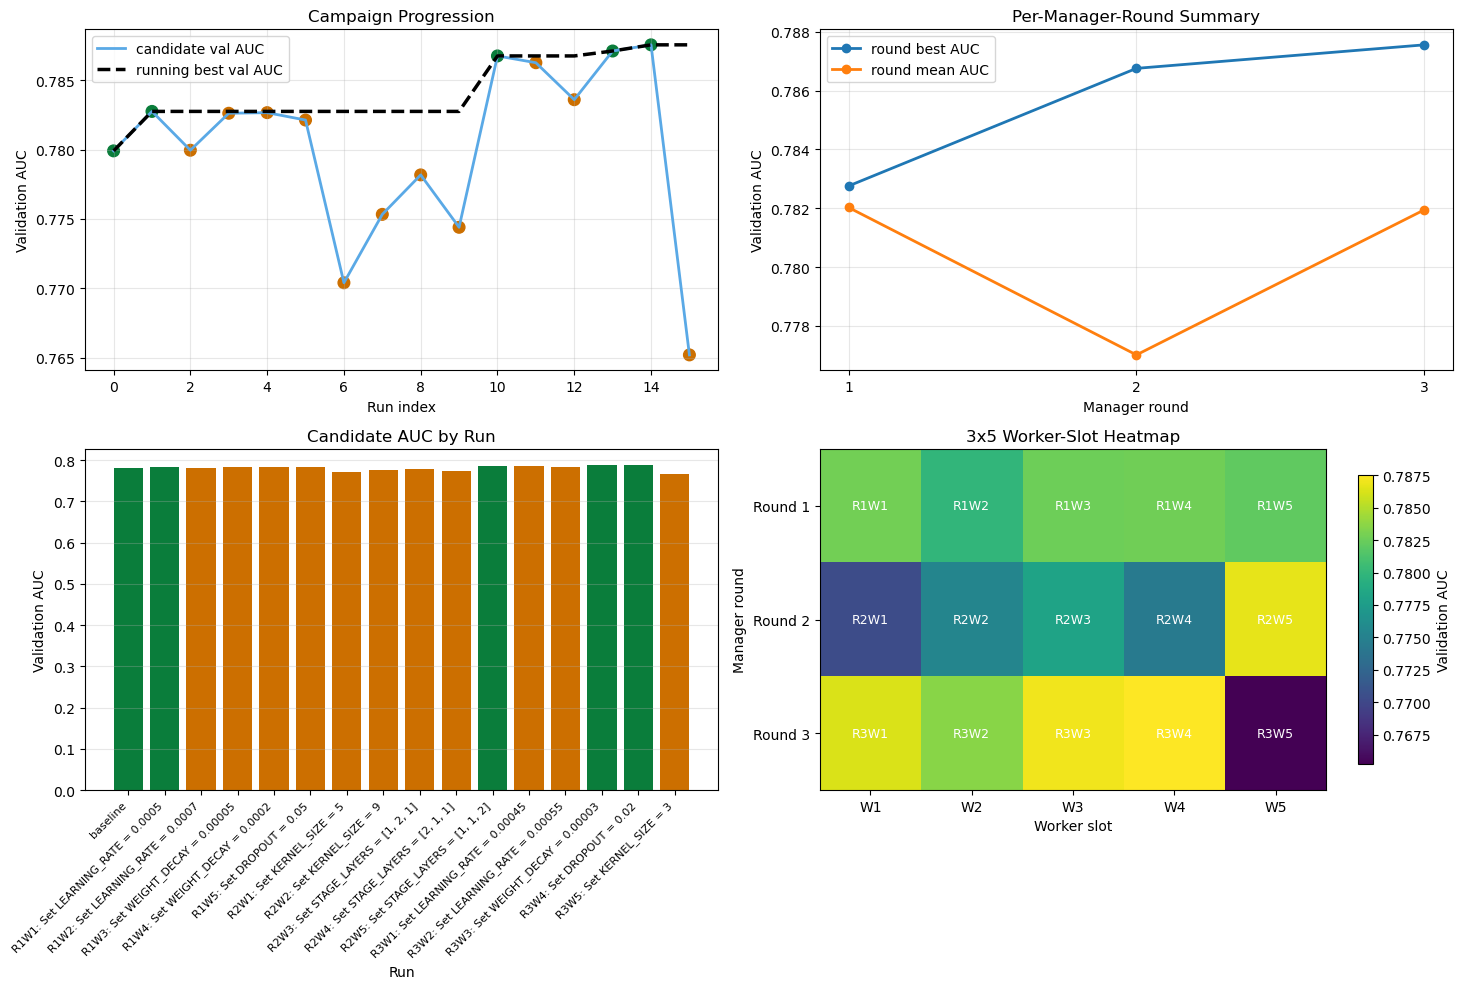

In [5]:
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
ax1, ax2, ax3, ax4 = axes.flatten()

x = list(range(len(rows)))
candidate_auc = [row['val_auc'] for row in rows]
status_colors = {'keep': '#0a7d3b', 'discard': '#cc6f00', 'crash': '#b00020'}
colors = [status_colors.get(row['status'], '#666666') for row in rows]

ax1.plot(x, candidate_auc, color='#5aa9e6', linewidth=2, label='candidate val AUC')
ax1.plot(x, running_best, color='black', linewidth=2.5, linestyle='--', label='running best val AUC')
ax1.scatter(x, candidate_auc, c=colors, s=70)
ax1.set_title('Campaign Progression')
ax1.set_xlabel('Run index')
ax1.set_ylabel('Validation AUC')
ax1.grid(True, alpha=0.3)
ax1.legend()

round_to_values = {1: [], 2: [], 3: []}
for record in records:
    if record['val_bpb'] is not None:
        round_to_values[record['manager_round']].append(1.0 - float(record['val_bpb']))

round_ids = [1, 2, 3]
round_best = [max(round_to_values[r]) if round_to_values[r] else math.nan for r in round_ids]
round_mean = [float(np.mean(round_to_values[r])) if round_to_values[r] else math.nan for r in round_ids]
ax2.plot(round_ids, round_best, marker='o', linewidth=2, label='round best AUC')
ax2.plot(round_ids, round_mean, marker='o', linewidth=2, label='round mean AUC')
ax2.set_title('Per-Manager-Round Summary')
ax2.set_xlabel('Manager round')
ax2.set_ylabel('Validation AUC')
ax2.set_xticks(round_ids)
ax2.grid(True, alpha=0.3)
ax2.legend()

labels = [row['description'].replace('baseline', 'baseline') for row in rows]
ax3.bar(x, candidate_auc, color=colors)
ax3.set_title('Candidate AUC by Run')
ax3.set_xlabel('Run')
ax3.set_ylabel('Validation AUC')
ax3.set_xticks(x)
ax3.set_xticklabels(labels, rotation=45, ha='right', fontsize=8)
ax3.grid(True, axis='y', alpha=0.3)

heatmap = np.full((3, 5), np.nan)
for record in records:
    round_index = int(record['manager_round']) - 1
    worker_index = int(record['slot'].split('W')[1]) - 1
    heatmap[round_index, worker_index] = 1.0 - float(record['val_bpb'])

im = ax4.imshow(heatmap, cmap='viridis', aspect='auto')
for record in records:
    round_index = int(record['manager_round']) - 1
    worker_index = int(record['slot'].split('W')[1]) - 1
    ax4.text(worker_index, round_index, record['slot'], ha='center', va='center', color='white', fontsize=9)
ax4.set_title('3x5 Worker-Slot Heatmap')
ax4.set_xlabel('Worker slot')
ax4.set_ylabel('Manager round')
ax4.set_xticks(range(5))
ax4.set_xticklabels(['W1', 'W2', 'W3', 'W4', 'W5'])
ax4.set_yticks(range(3))
ax4.set_yticklabels(['Round 1', 'Round 2', 'Round 3'])
fig.colorbar(im, ax=ax4, shrink=0.85, label='Validation AUC')

plt.tight_layout()
plt.show()

## Epoch-Level Curves For Best Runs

This cell pulls the archived histories and plots validation AUC across epochs for the best kept configurations.

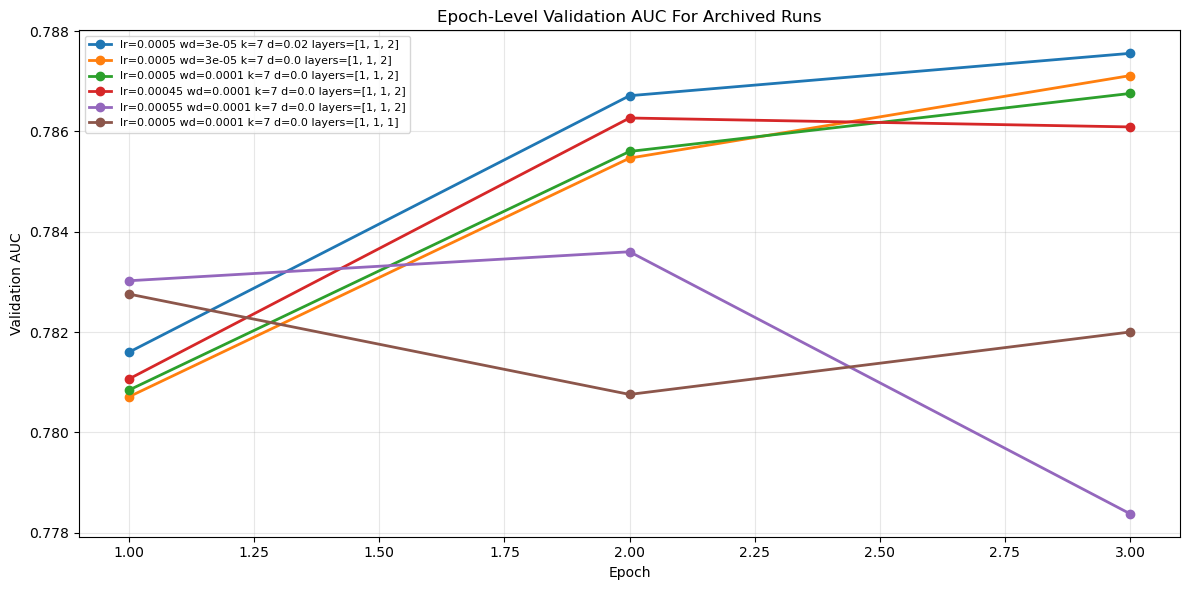

In [6]:
archive_payloads = []
for path in sorted(RUN_ARCHIVE_DIR.glob('*.json')):
    payload = json.loads(path.read_text())
    archive_payloads.append((path.name, payload))

best_by_signature = {}
for name, payload in archive_payloads:
    config = payload.get('config', {})
    history = payload.get('history', [])
    if not history:
        continue
    signature = (
        config.get('learning_rate'),
        config.get('weight_decay'),
        tuple(config.get('stage_layers', [])),
        config.get('kernel_size'),
        config.get('dropout'),
    )
    best_auc = max(row['val_auc'] for row in history)
    previous = best_by_signature.get(signature)
    if previous is None or best_auc > previous[1]:
        best_by_signature[signature] = ((name, payload), best_auc)

selected = sorted((item[0] for item in best_by_signature.values()), key=lambda pair: max(row['val_auc'] for row in pair[1].get('history', [])), reverse=True)[:6]

plt.figure(figsize=(12, 6))
for name, payload in selected:
    config = payload.get('config', {})
    history = payload.get('history', [])
    if not history:
        continue
    epochs = [row['epoch'] for row in history]
    val_auc = [row['val_auc'] for row in history]
    label = f"lr={config.get('learning_rate')} wd={config.get('weight_decay')} k={config.get('kernel_size')} d={config.get('dropout')} layers={config.get('stage_layers')}"
    plt.plot(epochs, val_auc, marker='o', linewidth=2, label=label)

plt.title('Epoch-Level Validation AUC For Archived Runs')
plt.xlabel('Epoch')
plt.ylabel('Validation AUC')
plt.grid(True, alpha=0.3)
plt.legend(fontsize=8, loc='best')
plt.tight_layout()
plt.show()